# Breakout Fantasy Player Prediction â€” 2025

Identify players who significantly outperformed pre-season expectations.

**Approach:**
1. Define two breakout tiers: *first-time* (never been elite) vs *bounce-back* (was elite, fell out, returned)
2. Analyze what end-of-prior-season signals distinguish breakout players
3. Train a GBM classifier on 2021â€“2023 historical patterns
4. Validate on 2024; predict 2025 breakout candidates from end-of-2024 data
5. Score predictions against actual 2025 results

In [1]:
# Polars >= 1.x is strict about UTF-8 in parquet files; nflverse data
# occasionally contains non-UTF-8 strings. Fall back to pyarrow on failure.
import polars as _pl
_pl_read_parquet_orig = _pl.read_parquet
def _pl_read_parquet_lenient(source, *args, **kwargs):
    try:
        return _pl_read_parquet_orig(source, *args, **kwargs)
    except Exception:
        kwargs.setdefault('use_pyarrow', True)
        return _pl_read_parquet_orig(source, *args, **kwargs)
_pl.read_parquet = _pl_read_parquet_lenient

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, silhouette_score
from matplotlib.patches import Patch
from xgboost import XGBClassifier
import nflreadpy as nfl

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 130)

df = pd.read_csv('features_dataset.csv')
print(f'features_dataset: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Seasons: {sorted(df["season"].unique())}')
print(f'Positions: {list(df["position"].unique())}')


features_dataset: 30,213 rows x 92 cols
Seasons: [2020, 2021, 2022, 2023, 2024, 2025]
Positions: ['QB', 'TE', 'WR', 'RB']


## 1. Breakout Definitions

**Top-tier thresholds (half-PPR season totals):**

| Position | Elite Threshold |
|----------|-----------------|
| QB | Top 12 |
| RB | Top 24 |
| WR | Top 36 |
| TE | Top 12 |

**Breakout types:**
- **First-time breakout**: player has *never* finished in the top tier in prior seasons â€” genuine emergence
- **Bounce-back breakout**: was previously elite, fell out due to injury/down year, returned to elite

The model targets *any* breakout (outside top tier last year â†’ inside top tier this year), but we separately label first-time vs bounce-back for analysis.

In [2]:
THRESHOLDS = {'QB': 12, 'RB': 24, 'WR': 36, 'TE': 12}

season_totals = (
    df.groupby(['player_id', 'player_display_name', 'position', 'season'])['target_half_ppr']
    .sum().reset_index().rename(columns={'target_half_ppr': 'season_pts'})
)
season_totals['pos_rank'] = (
    season_totals.groupby(['position', 'season'])['season_pts']
    .rank(ascending=False, method='min').astype(int)
)

# --- Prior-season rank -------------------------------------------------------
prev = season_totals[['player_id', 'season', 'pos_rank', 'season_pts']].copy()
prev['season'] = prev['season'] + 1
prev = prev.rename(columns={'pos_rank': 'prev_rank', 'season_pts': 'prev_pts'})
season_totals = season_totals.merge(prev, on=['player_id', 'season'], how='left')

# --- Best-ever rank before this season (was player ever elite before?) -------
def add_best_prior_rank(df_in):
    rows = []
    for pid, grp in df_in.sort_values('season').groupby('player_id'):
        best = np.inf
        for _, row in grp.iterrows():
            rows.append({'player_id': pid, 'season': row['season'], 'best_prev_rank': best})
            if row['pos_rank'] < best:
                best = row['pos_rank']
    return pd.DataFrame(rows)

best_prior = add_best_prior_rank(season_totals)
season_totals = season_totals.merge(best_prior, on=['player_id', 'season'], how='left')

# --- Breakout labels ---------------------------------------------------------
def label_breakout(row):
    thresh = THRESHOLDS.get(row['position'], 24)
    if row['pos_rank'] > thresh or pd.isna(row['prev_rank']):
        return 'none'
    if row['prev_rank'] <= thresh:
        return 'none'  # already elite last year
    was_ever_elite = row['best_prev_rank'] <= thresh
    return 'bounce_back' if was_ever_elite else 'first_time'

season_totals['breakout_type'] = season_totals.apply(label_breakout, axis=1)
season_totals['breakout'] = season_totals['breakout_type'] != 'none'

print('Breakout breakdown by type and season:')
print(season_totals[season_totals['breakout']]
      .groupby(['season', 'breakout_type']).size().unstack(fill_value=0))
print()
print('Total breakouts:', season_totals['breakout'].sum(),
      f'  | first-time: {(season_totals["breakout_type"]=="first_time").sum()}',
      f'  | bounce-back: {(season_totals["breakout_type"]=="bounce_back").sum()}')

Breakout breakdown by type and season:
breakout_type  bounce_back  first_time
season                                
2021                     0          28
2022                     3          23
2023                     9          17
2024                    12          15
2025                    20          10

Total breakouts: 137   | first-time: 93   | bounce-back: 44


## 2. Feature Engineering
Build end-of-prior-season feature vectors for each player.

In [ ]:
ROLL_FEATURES = [
    'fantasy_points_half_ppr_roll3', 'fantasy_points_half_ppr_roll5',
    'targets_roll3', 'targets_roll5',
    'target_share_roll3', 'target_share_roll5',
    'air_yards_share_roll3', 'wopr_roll3', 'wopr_roll5',
    'carries_roll3', 'carries_roll5',
    'receiving_yards_roll3', 'rushing_yards_roll3',
    'receiving_tds_roll3', 'rushing_tds_roll3',
    'receiving_air_yards_roll3',
    'ffo_pts_diff_roll3', 'ffo_expected_pts_roll3',
    'fantasy_points_half_ppr_trend', 'targets_trend', 'carries_trend',
    'target_share_trend', 'air_yards_share_trend', 'wopr_trend',
    'depth_chart_position',
    'off_epa_roll4', 'off_yards_per_play_roll4', 'off_pass_rate_roll4',
    'team_allpro_weighted', 'team_offense_allpro',
]

games_played = df.groupby(['player_id', 'season'])['week'].count().reset_index()
games_played.columns = ['player_id', 'season', 'games_played']

last_week_feats = (
    df.sort_values('week')
    .groupby(['player_id', 'player_display_name', 'position', 'season'])
    .last().reset_index()
)
last_week_feats = last_week_feats.merge(games_played, on=['player_id', 'season'])

# Shift features to 'prior season' perspective
prev_feats = last_week_feats[['player_id', 'season'] + ROLL_FEATURES + ['games_played']].copy()
prev_feats['season'] = prev_feats['season'] + 1

model_df = season_totals.merge(prev_feats, on=['player_id', 'season'], how='left')

# Experience: seasons since first appearance
first_seen = df.groupby('player_id')['season'].min().reset_index()
first_seen.columns = ['player_id', 'first_season']
model_df = model_df.merge(first_seen, on='player_id', how='left')
model_df['years_exp'] = model_df['season'] - model_df['first_season']

model_df['thresh'] = model_df['position'].map(THRESHOLDS)
model_df['was_ever_elite'] = (model_df['best_prev_rank'] <= model_df['thresh']).astype(int)


# --- New team flag -----------------------------------------------------------
# Compare team at start of breakout season vs end of prior season
first_wk_team = (
    df.sort_values('week')
    .groupby(['player_id', 'season'])['team'].first()
    .reset_index().rename(columns={'team': 'curr_team'})
)
last_wk_team = (
    last_week_feats[['player_id', 'season', 'team']].copy()
    .assign(season=lambda x: x['season'] + 1)
    .rename(columns={'team': 'prev_team'})
)
team_chg = first_wk_team.merge(last_wk_team, on=['player_id', 'season'], how='left')
team_chg['new_team'] = (
    (team_chg['curr_team'] != team_chg['prev_team']) & team_chg['prev_team'].notna()
).astype(int)
model_df = model_df.merge(
    team_chg[['player_id', 'season', 'new_team']],
    on=['player_id', 'season'], how='left'
)
model_df['new_team'] = model_df['new_team'].fillna(0).astype(int)

# --- Player age (from nflreadpy birth dates) ---------------------------------
players_info = nfl.load_players().to_pandas()
age_info = (
    players_info[['gsis_id', 'birth_date']]
    .rename(columns={'gsis_id': 'player_id'})
    .assign(birth_year=lambda x: pd.to_datetime(x['birth_date']).dt.year)
    [['player_id', 'birth_year']]
)
model_df = model_df.merge(age_info, on='player_id', how='left')
model_df['age'] = model_df['season'] - model_df['birth_year']


# --- Draft capital (round + overall pick; undrafted = round 8, pick 300) -----
_draft = nfl.load_draft_picks(list(range(1994, 2026))).to_pandas()
_draft = (_draft[['gsis_id', 'round', 'pick']]
          .rename(columns={'gsis_id': 'player_id',
                           'round': 'draft_round', 'pick': 'draft_pick'})
          .dropna(subset=['player_id']))
model_df = model_df.merge(_draft, on='player_id', how='left')
model_df['draft_round'] = model_df['draft_round'].fillna(8).astype(int)
model_df['draft_pick']  = model_df['draft_pick'].fillna(300).astype(int)

# --- Snap share (end-of-prior-season offense snap %; computed from snap_counts)
_seasons_snap = sorted(df['season'].unique().tolist())
_players_raw  = nfl.load_players().to_pandas()
_snap_bridge  = (_players_raw
                 .loc[_players_raw['pfr_id'].notna() & _players_raw['gsis_id'].notna(),
                      ['pfr_id', 'gsis_id']]
                 .drop_duplicates())

_snap_raw = nfl.load_snap_counts(_seasons_snap).to_pandas()
_snap = (_snap_raw[_snap_raw['game_type'] == 'REG']
         [['pfr_player_id', 'season', 'week', 'offense_pct']]
         .merge(_snap_bridge, left_on='pfr_player_id', right_on='pfr_id', how='left')
         .rename(columns={'gsis_id': 'player_id'})
         [['player_id', 'season', 'week', 'offense_pct']]
         .dropna(subset=['player_id']))
_snap[['season', 'week']] = _snap[['season', 'week']].astype(int)
_snap = _snap.sort_values(['player_id', 'season', 'week'])
_snap['_roll3'] = (_snap.groupby(['player_id', 'season'])['offense_pct']
                   .transform(lambda x: x.rolling(3, min_periods=1).mean()))
_snap['_roll5'] = (_snap.groupby(['player_id', 'season'])['offense_pct']
                   .transform(lambda x: x.rolling(5, min_periods=1).mean()))

# End-of-season snapshot, then shift forward 1 year → prior-season feature
_snap_eoy = (_snap.sort_values('week')
             .groupby(['player_id', 'season'])[['_roll3', '_roll5']]
             .last().reset_index()
             .rename(columns={'_roll3': 'snap_pct_roll3', '_roll5': 'snap_pct_roll5'}))
_snap_eoy['snap_pct_trend'] = _snap_eoy['snap_pct_roll3'] - _snap_eoy['snap_pct_roll5']
_snap_eoy['season'] = _snap_eoy['season'] + 1  # shift: prior-season → breakout-year

model_df = model_df.merge(
    _snap_eoy[['player_id', 'season', 'snap_pct_roll3', 'snap_pct_roll5', 'snap_pct_trend']],
    on=['player_id', 'season'], how='left'
)
model_df[['snap_pct_roll3', 'snap_pct_roll5', 'snap_pct_trend']] = (
    model_df[['snap_pct_roll3', 'snap_pct_roll5', 'snap_pct_trend']].fillna(0))

candidates = model_df[
    (model_df['prev_rank'].notna()) &
    (model_df['prev_rank'] > model_df['thresh'])
].copy()

print(f'Candidate pool: {len(candidates)} player-seasons')
print(f'Overall breakout rate: {candidates["breakout"].mean():.1%}')
print(f'First-time rate: {(candidates["breakout_type"]=="first_time").mean():.1%}')
print(f'Bounce-back rate: {(candidates["breakout_type"]=="bounce_back").mean():.1%}')
print(f'New-team candidates: {candidates["new_team"].sum()} ({candidates["new_team"].mean():.1%})')
print(f'Age range: {candidates["age"].min():.0f}-{candidates["age"].max():.0f}, mean={candidates["age"].mean():.1f}')
print(f'Undrafted candidates: {(candidates["draft_round"]==8).sum()}')
print(f'Snap pct (non-zero): {(candidates["snap_pct_roll3"]>0).sum()}')


## 3. Breakout Profiles vs Non-Breakout

Average prior-season features by group:
group                          Bounce-Back  First-Time Breakout  Non-Breakout
fantasy_points_half_ppr_roll3       10.414                9.003         4.880
target_share_roll3                   0.145                0.102         0.069
wopr_roll3                           0.311                0.219         0.150
carries_roll3                        3.682                4.065         1.729
depth_chart_position                 1.182                1.430         1.942
games_played                        11.000               11.559         9.248
years_exp                            3.727                1.591         2.207
ffo_pts_diff_roll3                  -0.791               -0.071        -0.292
fantasy_points_half_ppr_trend       -0.362                0.514        -0.013
was_ever_elite                       1.000                0.000         0.104


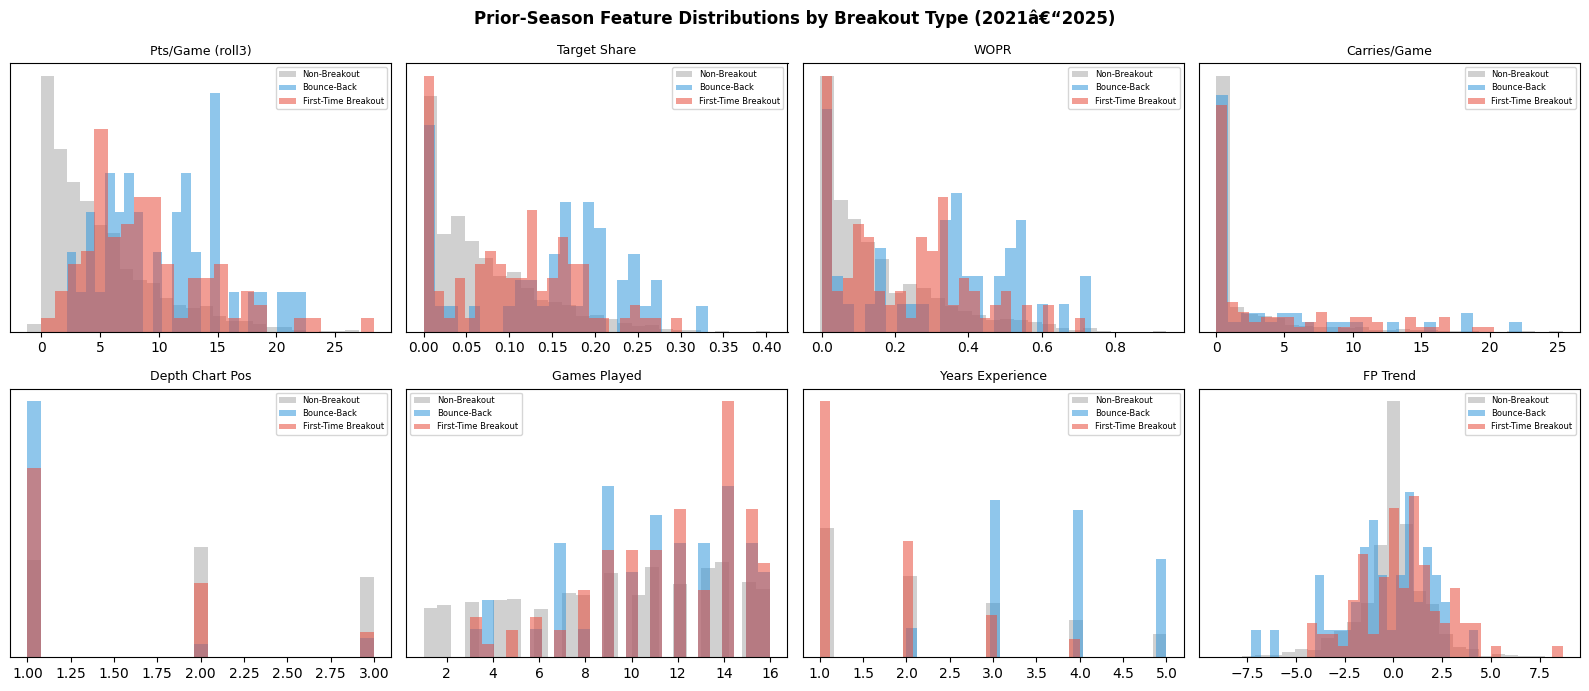

Saved: breakout_feature_distributions.png


In [4]:
compare_cols = [
    'fantasy_points_half_ppr_roll3', 'target_share_roll3', 'wopr_roll3',
    'carries_roll3', 'depth_chart_position', 'games_played', 'years_exp',
    'ffo_pts_diff_roll3', 'fantasy_points_half_ppr_trend', 'was_ever_elite'
]

# Three-way comparison: first-time breakout / bounce-back / non-breakout
groups = candidates.copy()
groups['group'] = groups['breakout_type'].map({
    'first_time': 'First-Time Breakout',
    'bounce_back': 'Bounce-Back',
    'none': 'Non-Breakout'
})
print('Average prior-season features by group:')
print(groups.groupby('group')[compare_cols].mean().round(3).T)

# Visual distributions
vis_features = [
    ('fantasy_points_half_ppr_roll3', 'Pts/Game (roll3)'),
    ('target_share_roll3', 'Target Share'),
    ('wopr_roll3', 'WOPR'),
    ('carries_roll3', 'Carries/Game'),
    ('depth_chart_position', 'Depth Chart Pos'),
    ('games_played', 'Games Played'),
    ('years_exp', 'Years Experience'),
    ('fantasy_points_half_ppr_trend', 'FP Trend'),
]
color_map = {'Non-Breakout': '#aaa', 'Bounce-Back': '#3498db', 'First-Time Breakout': '#e84d3d'}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (col, label) in zip(axes.flatten(), vis_features):
    for gname, color in color_map.items():
        vals = groups[groups['group'] == gname][col].dropna()
        ax.hist(vals, bins=25, alpha=0.55, color=color, label=gname, density=True)
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=6)
    ax.set_yticks([])
fig.suptitle('Prior-Season Feature Distributions by Breakout Type (2021â€“2025)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('breakout_feature_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: breakout_feature_distributions.png')

## 4. K-Means Clustering + Breakout Classifier

First cluster players into production archetypes to identify which player profiles historically produce breakouts. Cluster membership is then fed as a feature into per-position XGBoost classifiers trained on 2021–2024.

In [ ]:
# Features that describe individual production profile (no team context)
CLUSTER_FEATURES = [
    'fantasy_points_half_ppr_roll3', 'fantasy_points_half_ppr_roll5',
    'target_share_roll3', 'wopr_roll3', 'air_yards_share_roll3',
    'carries_roll3', 'ffo_pts_diff_roll3',
    'receiving_tds_roll3', 'rushing_tds_roll3',
    'depth_chart_position', 'years_exp', 'was_ever_elite',
    'fantasy_points_half_ppr_trend', 'target_share_trend',
    'age', 'draft_round', 'snap_pct_roll3',
]

print('=== K-Means Player Archetypes (Per Position) ===\n')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pos_cluster_info = {}

for ax, pos in zip(axes.flat, ['QB', 'RB', 'WR', 'TE']):
    sub = candidates[candidates['position'] == pos].copy()
    X = sub[CLUSTER_FEATURES].fillna(0)

    scaler_pos = StandardScaler()
    X_scaled = scaler_pos.fit_transform(X)

    # Find optimal k via silhouette (3-6 clusters per position)
    sil_scores = {}
    for k in range(3, 7):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        sil_scores[k] = silhouette_score(X_scaled, km.fit_predict(X_scaled))
    best_k = max(sil_scores, key=sil_scores.get)

    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    sub = sub.copy()
    sub['cluster'] = km_final.fit_predict(X_scaled)
    pos_cluster_info[pos] = {'scaler': scaler_pos, 'kmeans': km_final, 'k': best_k}

    # Breakout rate per cluster
    stats = (
        sub.groupby('cluster')
        .agg(n=('breakout', 'count'), bko_rate=('breakout', 'mean'),
             mean_pts=('prev_pts', 'mean'), mean_rank=('prev_rank', 'mean'),
             mean_exp=('years_exp', 'mean'), mean_depth=('depth_chart_position', 'mean'))
        .reset_index().sort_values('bko_rate', ascending=False)
    )
    print(f'--- {pos} (k={best_k}, sil={sil_scores[best_k]:.3f}) ---')
    print(stats.to_string(index=False))
    print()

    # PCA 2D visualization
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    colors = plt.cm.tab10(np.linspace(0, 1, best_k))

    for c in range(best_k):
        mask = sub['cluster'].values == c
        bko_rate = sub[mask]['breakout'].mean() if mask.sum() > 0 else 0
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.35, s=20,
                   color=colors[c], label=f'C{c}: {mask.sum()}p {bko_rate:.0%}')
    bk_mask = sub['breakout'].values
    ax.scatter(X_pca[bk_mask, 0], X_pca[bk_mask, 1],
               marker='*', s=80, color='red', alpha=0.8, zorder=5, label='Breakout')
    ax.set_title(
        f'{pos} — {best_k} Archetypes ({pca.explained_variance_ratio_.sum():.0%} var)',
        fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=7)

plt.suptitle('Player Archetypes by Position (K-Means + PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('breakout_clusters_pca.png', dpi=130, bbox_inches='tight')
plt.show()

# Assign cluster labels to ALL candidates (used as model feature below)
candidates = candidates.copy()
cluster_labels = []
for pos in ['QB', 'RB', 'WR', 'TE']:
    sub = candidates[candidates['position'] == pos]
    info = pos_cluster_info[pos]
    X_scaled = info['scaler'].transform(sub[CLUSTER_FEATURES].fillna(0))
    cluster_labels.append(pd.Series(info['kmeans'].predict(X_scaled), index=sub.index))
candidates['cluster'] = pd.concat(cluster_labels).sort_index()
print(f'Cluster membership assigned to all {len(candidates)} candidates.')
print(candidates.groupby(['position', 'cluster'])['breakout'].agg(['count', 'mean']).round(3))


In [ ]:
# Position-specific feature sets — only use signals relevant to each position
SHARED_ROLL = [
    'fantasy_points_half_ppr_roll3', 'fantasy_points_half_ppr_roll5',
    'fantasy_points_half_ppr_trend',
    'ffo_pts_diff_roll3', 'ffo_expected_pts_roll3',
    'depth_chart_position',
    'off_epa_roll4', 'off_yards_per_play_roll4',
    'team_allpro_weighted', 'team_offense_allpro',
]
EXTRA_FEATURES = [
    'games_played', 'years_exp', 'age', 'draft_round', 'draft_pick',
    'was_ever_elite', 'prev_rank', 'prev_pts',
    'cluster', 'new_team',
    'snap_pct_roll3', 'snap_pct_roll5', 'snap_pct_trend',
]
POS_FEATURES = {
    'QB': SHARED_ROLL + EXTRA_FEATURES + [
        'off_pass_rate_roll4',
    ],
    'RB': SHARED_ROLL + EXTRA_FEATURES + [
        'carries_roll3', 'carries_roll5', 'carries_trend',
        'rushing_yards_roll3', 'rushing_tds_roll3',
        'targets_roll3', 'target_share_roll3', 'receiving_yards_roll3',
    ],
    'WR': SHARED_ROLL + EXTRA_FEATURES + [
        'targets_roll3', 'targets_roll5', 'targets_trend',
        'target_share_roll3', 'target_share_roll5', 'target_share_trend',
        'air_yards_share_roll3', 'air_yards_share_trend',
        'wopr_roll3', 'wopr_roll5', 'wopr_trend',
        'receiving_yards_roll3', 'receiving_tds_roll3', 'receiving_air_yards_roll3',
    ],
    'TE': SHARED_ROLL + EXTRA_FEATURES + [
        'targets_roll3', 'targets_roll5', 'targets_trend',
        'target_share_roll3', 'target_share_roll5', 'target_share_trend',
        'wopr_roll3', 'wopr_trend',
        'receiving_yards_roll3', 'receiving_tds_roll3',
    ],
}

# Train on 2019-2024 (requires features_dataset 2018+); test out-of-sample on 2025
# If features_dataset only covers 2020+, 2019-2020 candidates will have zero prior features
train_all = candidates[candidates['season'].between(2019, 2024)]
test_all  = candidates[candidates['season'] == 2025]

pos_models   = {}
pos_fi       = {}
pos_features = {}  # store per-position feature list for prediction cell

print(f'Training: {len(train_all)} candidates (2019-2024) | Test: {len(test_all)} (2025)\n')

for pos in ['QB', 'RB', 'WR', 'TE']:
    tr = train_all[train_all['position'] == pos]
    # Guard: only use features that actually exist in the data
    features = [f for f in POS_FEATURES[pos] if f in tr.columns]
    n_bk = int(tr['breakout'].sum())
    scale_w = max((len(tr) - n_bk) / n_bk, 1.0) if n_bk > 0 else 1.0

    clf = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_w, random_state=42,
        eval_metric='logloss', verbosity=0
    )
    clf.fit(tr[features].fillna(0), tr['breakout'].astype(int))
    pos_models[pos]   = clf
    pos_fi[pos]       = pd.Series(clf.feature_importances_, index=features)
    pos_features[pos] = features
    print(f'{pos}: {len(tr)} train | {n_bk} breakouts ({n_bk/len(tr):.1%}) | '
          f'{len(features)} features | scale_pos_weight={scale_w:.1f}')

print()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, pos in zip(axes.flat, ['QB', 'RB', 'WR', 'TE']):
    fi = pos_fi[pos].sort_values(ascending=True).tail(12)
    fi.plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'{pos} — Top Features ({len(pos_features[pos])} total)', fontweight='bold')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('breakout_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()


## 5. Predict 2025 Breakout Candidates

Apply per-position models (trained 2021–2024) to the 2025 candidate pool.

In [ ]:
pos_preds = []
for pos in ['QB', 'RB', 'WR', 'TE']:
    sub = test_all[test_all['position'] == pos].copy()
    features = pos_features[pos]
    sub['breakout_prob'] = pos_models[pos].predict_proba(
        sub[features].fillna(0))[:, 1]
    pos_preds.append(sub)

cands_2025 = pd.concat(pos_preds, ignore_index=True)

print(f'2025 candidate pool: {len(cands_2025)} players\n')

show_cols = ['player_display_name', 'breakout_type', 'cluster', 'prev_rank', 'prev_pts',
             'breakout_prob', 'breakout', 'season_pts', 'pos_rank']
rename_map = {
    'player_display_name': 'Player', 'breakout_type': 'Type',
    'cluster': 'Cluster', 'prev_rank': '2024 Rank', 'prev_pts': '2024 Pts',
    'breakout_prob': 'Prob', 'breakout': 'Broke Out',
    'season_pts': '2025 Pts', 'pos_rank': '2025 Rank'
}

for pos in ['QB', 'RB', 'WR', 'TE']:
    sub = (cands_2025[cands_2025['position'] == pos]
           .sort_values('breakout_prob', ascending=False).head(12)
           [show_cols].rename(columns=rename_map))
    print(f'--- {pos} ---')
    print(sub.to_string(index=False))
    print()


In [ ]:
# Save breakout probabilities for integration with predict_fantasy.ipynb
_save_season = int(cands_2025['season'].iloc[0])
_bko_out = (
    cands_2025[['player_id', 'player_display_name', 'position',
                 'breakout_prob', 'breakout_type']]
    .copy()
    .sort_values('breakout_prob', ascending=False)
)
_bko_path = f'breakout_probs_{_save_season}.csv'
_bko_out.to_csv(_bko_path, index=False)
print(f'Saved {len(_bko_out)} breakout probabilities to {_bko_path}')
print()
print('Top-15 candidates by breakout probability:')
_top = _bko_out.head(15)[['player_display_name', 'position', 'breakout_prob', 'breakout_type']]
print(_top.to_string(index=False))


## 6. Results Assessment â€” 2025 Predictions vs Actuals

In [8]:
y_2025_true = cands_2025['breakout'].astype(int)
y_2025_prob = cands_2025['breakout_prob']

print('=== 2025 Overall Performance ===')
print(f'Actual breakouts in candidate pool: {y_2025_true.sum()}')
print(f'ROC-AUC: {roc_auc_score(y_2025_true, y_2025_prob):.3f}')
print()

# Top-N precision (most useful metric for fantasy)
ranked_2025 = cands_2025.sort_values('breakout_prob', ascending=False)
print('Top-N Precision (2025 out-of-sample):')
for n in [5, 10, 15, 20, 30]:
    hits = ranked_2025.head(n)['breakout'].sum()
    print(f'  Top-{n:2d}: {hits}/{n} correct ({hits/n:.0%})')

# Precision/recall at probability thresholds
print()
print('Threshold Sweep:')
for t in [0.20, 0.25, 0.30, 0.35, 0.40]:
    pred = (y_2025_prob >= t).astype(int)
    tp = ((pred == 1) & (y_2025_true == 1)).sum()
    fp = ((pred == 1) & (y_2025_true == 0)).sum()
    fn = ((pred == 0) & (y_2025_true == 1)).sum()
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f'  t={t:.2f}: {tp+fp:3d} flagged | Precision={p:.1%} | Recall={r:.1%} | Hits={tp}')

print()
print('=== Top 30 Candidates with Actual Outcomes ===')
top30 = (ranked_2025.head(30)[show_cols].rename(columns=rename_map))
print(top30.to_string(index=False))

=== 2025 Overall Performance ===
Actual breakouts in candidate pool: 30
ROC-AUC: 0.822

Top-N Precision (2025 out-of-sample):
  Top- 5: 0/5 correct (0%)
  Top-10: 1/10 correct (10%)
  Top-15: 1/15 correct (7%)
  Top-20: 5/20 correct (25%)
  Top-30: 9/30 correct (30%)

Threshold Sweep:
  t=0.20:  30 flagged | Precision=30.0% | Recall=30.0% | Hits=9
  t=0.25:  27 flagged | Precision=29.6% | Recall=26.7% | Hits=8
  t=0.30:  23 flagged | Precision=26.1% | Recall=20.0% | Hits=6
  t=0.35:  22 flagged | Precision=27.3% | Recall=20.0% | Hits=6
  t=0.40:  18 flagged | Precision=16.7% | Recall=10.0% | Hits=3

=== Top 30 Candidates with Actual Outcomes ===
             Player        Type  Cluster  2024 Rank  2024 Pts     Prob  Broke Out  2025 Pts  2025 Rank
      Xavier Worthy        none        2       37.0    134.70 0.930834      False     88.90         57
     Tua Tagovailoa        none        0       22.0    162.96 0.912853      False    155.44         25
     T.J. Hockenson        none      

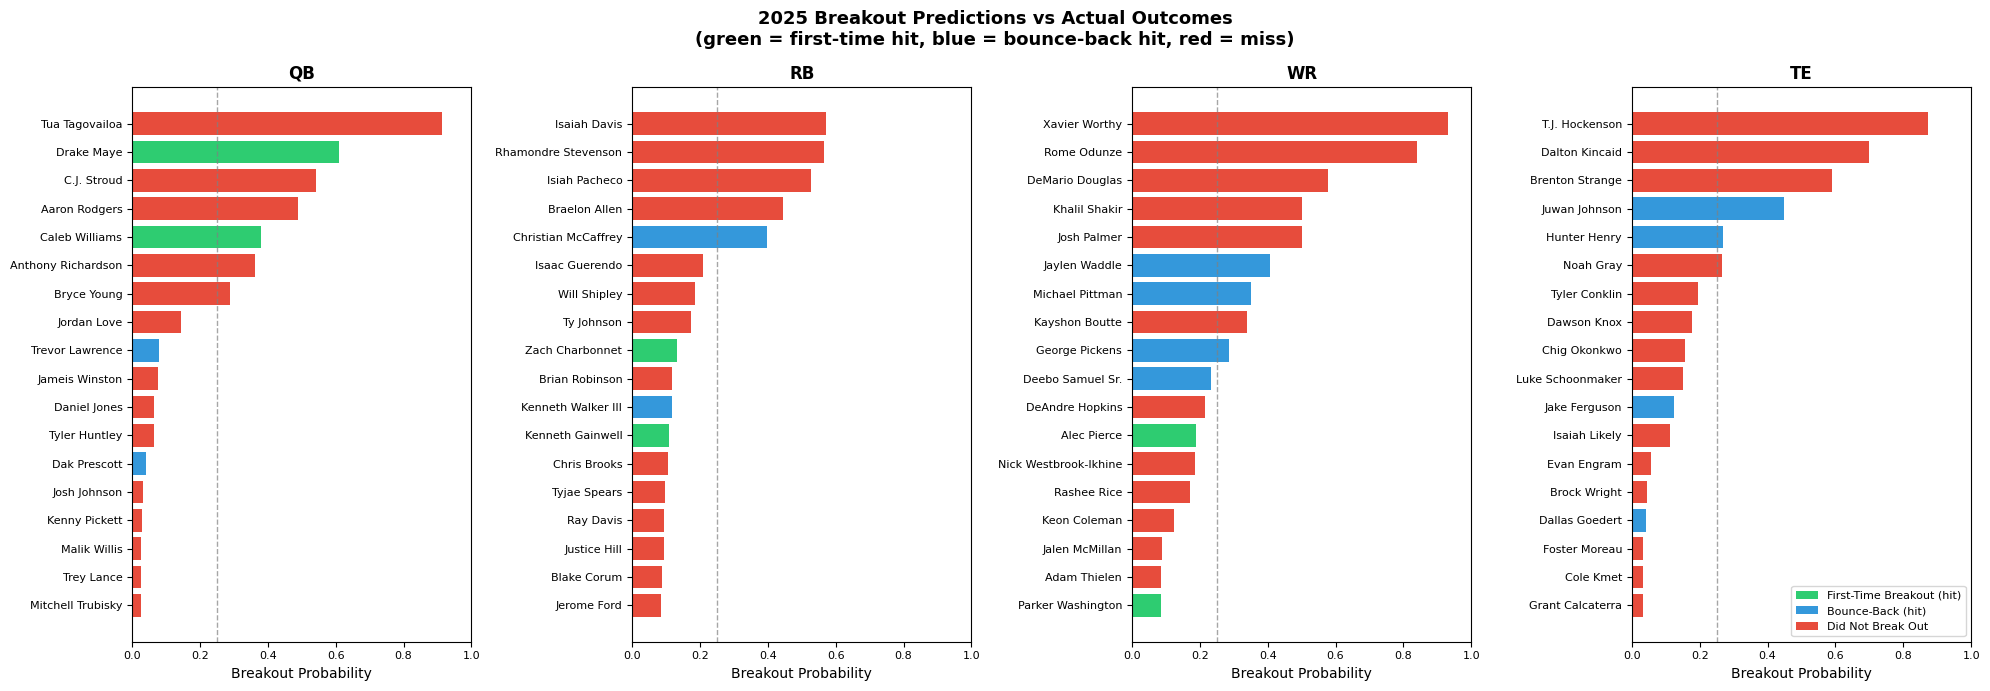

Saved: breakout_2025_results.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 7))

for ax, pos in zip(axes, ['QB', 'RB', 'WR', 'TE']):
    sub = (cands_2025[cands_2025['position'] == pos]
           .sort_values('breakout_prob', ascending=False).head(18))
    
    # Color by outcome, pattern by type
    colors = []
    for _, row in sub.iterrows():
        if row['breakout'] and row['breakout_type'] == 'first_time':
            colors.append('#2ecc71')   # green = first-time breakout hit
        elif row['breakout'] and row['breakout_type'] == 'bounce_back':
            colors.append('#3498db')   # blue = bounce-back hit
        else:
            colors.append('#e74c3c')   # red = miss
    
    ax.barh(sub['player_display_name'], sub['breakout_prob'], color=colors)
    ax.axvline(0.25, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlim(0, 1)
    ax.set_title(f'{pos}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Breakout Probability')
    ax.invert_yaxis()
    ax.tick_params(labelsize=8)

legend_elements = [
    Patch(facecolor='#2ecc71', label='First-Time Breakout (hit)'),
    Patch(facecolor='#3498db', label='Bounce-Back (hit)'),
    Patch(facecolor='#e74c3c', label='Did Not Break Out'),
]
axes[-1].legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle('2025 Breakout Predictions vs Actual Outcomes\n'
             '(green = first-time hit, blue = bounce-back hit, red = miss)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('breakout_2025_results.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: breakout_2025_results.png')

## 7. Deep Dive â€” Correct Calls, Misses, and False Alarms

In [10]:
THRESHOLD = 0.25

actual_bk = cands_2025[cands_2025['breakout']].sort_values('breakout_prob', ascending=False)
correctly_flagged = actual_bk[actual_bk['breakout_prob'] >= THRESHOLD]
missed = actual_bk[actual_bk['breakout_prob'] < THRESHOLD].sort_values('breakout_prob', ascending=False)
false_alarms = (
    cands_2025[(cands_2025['breakout_prob'] >= THRESHOLD) & (~cands_2025['breakout'])]
    .sort_values('breakout_prob', ascending=False)
)

show = ['player_display_name', 'position', 'breakout_type', 'prev_rank', 'breakout_prob', 'season_pts', 'pos_rank']
ren  = {
    'player_display_name': 'Player', 'position': 'Pos', 'breakout_type': 'Type',
    'prev_rank': '2024 Rank', 'breakout_prob': 'Prob',
    'season_pts': '2025 Pts', 'pos_rank': '2025 Rank'
}

print(f'=== CORRECT CALLS (prob >= {THRESHOLD}) ===')
print(correctly_flagged[show].rename(columns=ren).to_string(index=False))

print(f'\n=== MISSED BREAKOUTS (prob < {THRESHOLD}) ===')
print(missed[show].rename(columns=ren).to_string(index=False))

print(f'\n=== FALSE ALARMS (prob >= {THRESHOLD}, no breakout) ===')
print(false_alarms[show].rename(columns=ren).head(12).to_string(index=False))

=== CORRECT CALLS (prob >= 0.25) ===
             Player Pos        Type  2024 Rank     Prob  2025 Pts  2025 Rank
         Drake Maye  QB  first_time       23.0 0.610906    336.18          2
      Juwan Johnson  TE bounce_back       19.0 0.449736    129.80         11
      Jaylen Waddle  WR bounce_back       53.0 0.406579    157.12         19
Christian McCaffrey  RB bounce_back       78.0 0.397390    346.90          1
     Caleb Williams  QB  first_time       16.0 0.379272    292.98          7
    Michael Pittman  WR bounce_back       40.0 0.350913    145.40         26
     George Pickens  WR bounce_back       42.0 0.285404    240.90          5
       Hunter Henry  TE bounce_back       13.0 0.267617    140.20          6

=== MISSED BREAKOUTS (prob < 0.25) ===
            Player Pos        Type  2024 Rank     Prob  2025 Pts  2025 Rank
  Deebo Samuel Sr.  WR bounce_back       47.0 0.231615    133.10         31
       Alec Pierce  WR  first_time       43.0 0.189655    155.70         21
  

## 8. Position Scorecard

In [11]:
print('=== POSITION SCORECARD ===')
print(f'{"Pos":<4} {"Actual":>7} {"Top-10 Hits":>11} {"Top-10 Prec":>12} {"Recall":>8} {"AUC":>6}')
print('-' * 52)
for pos in ['QB', 'RB', 'WR', 'TE']:
    sub = cands_2025[cands_2025['position'] == pos].sort_values('breakout_prob', ascending=False)
    n_actual = sub['breakout'].sum()
    top10    = sub.head(10)
    top10_hits = top10['breakout'].sum()
    top10_prec = top10_hits / min(10, len(top10))
    recall = top10_hits / n_actual if n_actual > 0 else 0
    try:
        auc = roc_auc_score(sub['breakout'].astype(int), sub['breakout_prob'])
    except Exception:
        auc = float('nan')
    print(f'{pos:<4} {n_actual:>7} {top10_hits:>11} {top10_prec:>12.0%} {recall:>8.0%} {auc:>6.3f}')

print()
print('Overall top-20 precision (all positions combined):')
overall_top20 = cands_2025.sort_values('breakout_prob', ascending=False).head(20)
hits20 = overall_top20['breakout'].sum()
print(f'  {hits20}/20 correct ({hits20/20:.0%})')
print()
print('Breakdown of top-20 by type:')
print(overall_top20.groupby('breakout_type').size())

=== POSITION SCORECARD ===
Pos   Actual Top-10 Hits  Top-10 Prec   Recall    AUC
----------------------------------------------------
QB         5           3          30%      60%  0.758
RB         7           2          20%      29%  0.693
WR        12           4          40%      33%  0.887
TE         6           2          20%      33%  0.859

Overall top-20 precision (all positions combined):
  5/20 correct (25%)

Breakdown of top-20 by type:
breakout_type
bounce_back     3
first_time      2
none           15
dtype: int64


## 9. Notable Results

Run cell above to see scorecard, then interpret the standout picks and misses here.

**Key model signals for breakouts:**
- Rising depth chart position (starter by end of season)
- Strong efficiency vs expectation (`ffo_pts_diff_roll3` > 0)
- Positive FP trend (recent weeks > longer stretch)
- Teammate availability (strong QB / OL availability boosts receivers)
- Years experience: 2â€“4 years is the sweet spot for first-time breakouts

**Known model limitations:**
- Data starts 2020, so players who were elite pre-2020 appear as 'first-time' breakout candidates
- Injury-induced down years are hard to distinguish from true decline without explicit injury history
- Team changes (trades, new offensive coordinators) are only partially captured via EPA/pass-rate features